# 03 — Supervised: predict the cluster

The clustering notebook invented 3 groups with no labels. This notebook **learns those labels from examples**.

- Input: purchase features (`03_clustered.csv`)
- Target: `cluster_name`
- Split: **80% train**, **20% test** (stratified, so each group keeps the same share)
- Model: Random Forest
- Metric: accuracy on tickets the model has never seen

A Dummy “always guess the biggest group” baseline is included so 100% is not an empty number.

Output: `04_predictions.csv` (test set)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
TEST_SIZE = 0.20
CLUSTER_ORDER = ["Weekday morning", "Weekday evening", "Weekend"]

df = pd.read_csv("03_clustered.csv")
feature_cols = [c for c in df.columns if c not in ("cluster", "cluster_name")]
X = df[feature_cols]
y = df["cluster_name"]

print(f"rows={len(df)}  features={len(feature_cols)}")
y.value_counts().reindex(CLUSTER_ORDER)

rows=3636  features=14


cluster_name
Weekday morning    1246
Weekday evening    1474
Weekend             916
Name: count, dtype: int64

## Train / test split

80% of tickets are shown to the model **with** the correct cluster. The other 20% are held back. After training, we ask: on those unseen tickets, how often does it guess the right cluster?

`stratify=y` keeps the same mix of morning / evening / weekend in both sides. The scaler is fit **only on train**, then applied to test, so test numbers never leak into training.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

split = pd.DataFrame(
    {
        "train": y_train.value_counts(),
        "test": y_test.value_counts(),
    }
).reindex(CLUSTER_ORDER)
split["train_share"] = split["train"] / split["train"].sum()
split["test_share"] = split["test"] / split["test"].sum()
print(f"train={len(X_train)} ({1 - TEST_SIZE:.0%})  test={len(X_test)} ({TEST_SIZE:.0%})")
split.round(3)

train=2908 (80%)  test=728 (20%)


,train,test,train_share,test_share
cluster_name,,,,
Weekday morning,996,250,0.343,0.343
Weekday evening,1179,295,0.405,0.405
Weekend,733,183,0.252,0.251


## Train the model

**Dummy:** always predicts the most common cluster (Weekday evening). That is the score you get with no learning.

**Random Forest:** many decision trees vote on the cluster. Each tree sees a random slice of tickets and features, then the forest averages their votes.

In [3]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train_scaled, y_train)
y_dummy = dummy.predict(X_test_scaled)

forest = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
forest.fit(X_train_scaled, y_train)
y_pred = forest.predict(X_test_scaled)

dummy_acc = accuracy_score(y_test, y_dummy)
forest_acc = accuracy_score(y_test, y_pred)
print(f"Dummy accuracy (most frequent): {dummy_acc:.3f}")
print(f"Random Forest accuracy:         {forest_acc:.3f}")
print(f"Correct on test: {int(forest_acc * len(y_test))} / {len(y_test)}")
print()
print(classification_report(y_test, y_pred, labels=CLUSTER_ORDER, digits=3))

Dummy accuracy (most frequent): 0.405
Random Forest accuracy:         1.000
Correct on test: 728 / 728

                 precision    recall  f1-score   support

Weekday morning      1.000     1.000     1.000       250
Weekday evening      1.000     1.000     1.000       295
        Weekend      1.000     1.000     1.000       183

       accuracy                          1.000       728
      macro avg      1.000     1.000     1.000       728
   weighted avg      1.000     1.000     1.000       728



## Test visualizations

The confusion matrix counts, for each true cluster, which cluster the model predicted. A perfect diagonal means every test ticket was assigned to the right group.

Feature importance shows which columns the forest used most. Hour, weekday, and weekend should dominate: those are what K-Means used to build the groups.

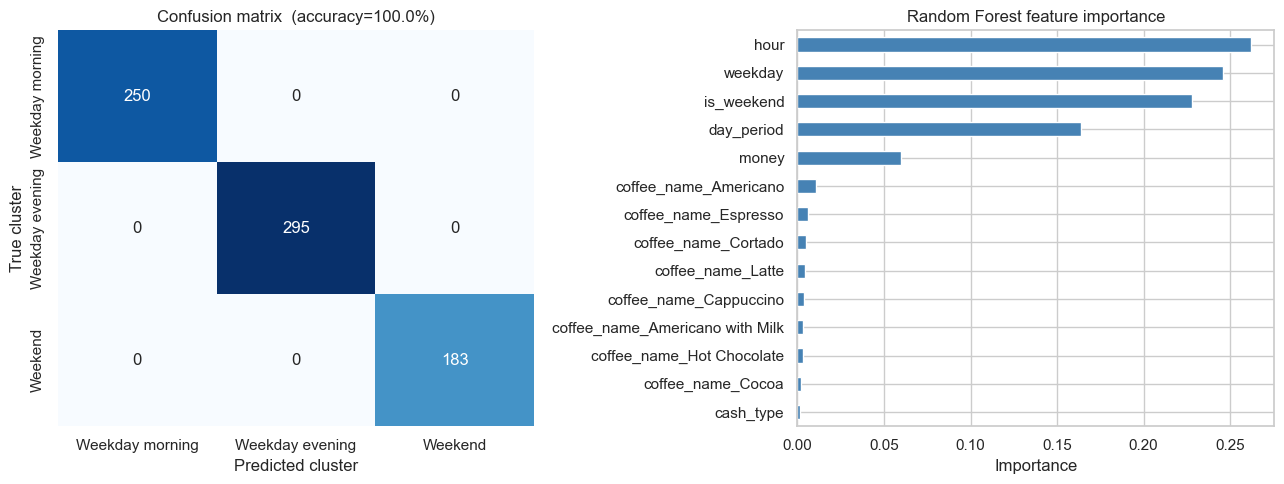

In [4]:
cm = confusion_matrix(y_test, y_pred, labels=CLUSTER_ORDER)
importance = (
    pd.Series(forest.feature_importances_, index=feature_cols)
    .sort_values(ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLUSTER_ORDER,
    yticklabels=CLUSTER_ORDER,
    ax=axes[0],
    cbar=False,
)
axes[0].set_title(f"Confusion matrix  (accuracy={forest_acc:.1%})")
axes[0].set_xlabel("Predicted cluster")
axes[0].set_ylabel("True cluster")

importance.plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Random Forest feature importance")
axes[1].set_xlabel("Importance")
fig.tight_layout()
plt.show()

In [5]:
pred_df = X_test.copy()
pred_df["cluster_true"] = y_test.values
pred_df["cluster_pred"] = y_pred
pred_df["correct"] = pred_df["cluster_true"] == pred_df["cluster_pred"]

out_path = Path("04_predictions.csv")
pred_df.to_csv(out_path, index=False)
print(f"Wrote {out_path}  shape={pred_df.shape}")
print(f"mistakes={int((~pred_df['correct']).sum())}")
pred_df.head()

Wrote 04_predictions.csv  shape=(728, 17)
mistakes=0


,money,weekday,is_weekend,day_period,hour,cash_type,coffee_name_Americano,coffee_name_Americano with Milk,coffee_name_Cappuccino,coffee_name_Cocoa,coffee_name_Cortado,coffee_name_Espresso,coffee_name_Hot Chocolate,coffee_name_Latte,cluster_true,cluster_pred,correct
2238,0.358318,3,0,2,16,0,1,0,0,0,0,0,0,0,Weekday evening,Weekday evening,True
2219,0.806216,1,0,2,14,0,0,0,0,0,0,0,0,1,Weekday evening,Weekday evening,True
797,0.671846,6,1,2,15,0,0,1,0,0,0,0,0,0,Weekend,Weekend,True
2322,0.358318,4,0,2,15,0,1,0,0,0,0,0,0,0,Weekday morning,Weekday morning,True
1947,0.806216,1,0,3,20,0,0,0,0,0,0,0,0,1,Weekday evening,Weekday evening,True


Near-perfect test accuracy is expected here. The clusters were **built from these same columns** (especially hour, weekday, weekend). The forest is learning that assignment rule, then proving it still works on tickets it was not trained on.

If Dummy is ~40% (always “Weekday evening”) and the forest is ~100%, the lift comes from actually using the features.